Imagine it's your first day at an exciting new job at a fast-growing tech company, Innovatech. You're filled with a mix of anticipation and nerves, eager to make a great first impression and contribute to your team. As you find your way to your desk, decorated with a welcoming note and some company swag, you can't help but feel a surge of pride. This is the moment you've been working towards, and it's finally here.

Your manager, Alex, greets you with a warm smile. "Welcome aboard! We're thrilled to have you with us. I have sent you a folder. Inside this folder, you'll find everything you need to get up to speed on our company policies, culture, and the projects your team is working on. Please keep them private."

You thank Alex and open the folder, only to be greeted by a mountain of documents - manuals, guidelines, technical documents, project summaries, and more. It's overwhelming. You think to yourself, "How am I supposed to absorb all of this information in a short time? And they are private and I cannot just upload it to GPT to summarize them." "Why not create an agent to read and summarize them for you, and then you can just ask it?" your colleague, Jordan, suggests with an encouraging grin. You're intrigued, but uncertain; the world of large language models (LLMs) is one that you've only scratched the surface of. Sensing your hesitation, Jordan elaborates, "Imagine having a personal assistant who's not only exceptionally fast at reading but can also understand and condense the information into easy-to-digest summaries. That's what an LLM can do for you, especially when enhanced with LangChain and Retrieval-Augmented Generation (RAG) technology."

"But how do I get started? And how long will it take to set up something like that?" you ask. Jordan says, "Let's dive into a project that will not only help you tackle this immediate challenge but also equip you with a skill set that's becoming indispensable in this field."

So, this project steps you through the fascinating world of LLMs and RAG, starting from the basics of what these technologies are, to building a practical application that can read and summarize documents for you. By the end of this tutorial, you have a working tool capable of processing the pile of documents on your desk, allowing you to focus on making meaningful contributions to your projects sooner.

What is RAG?
One of the most powerful applications enabled by LLMs is sophisticated question-answering (Q&A) chatbots. These are applications that can answer questions about specific source information. These applications use a technique known as retrieval-augmented generation (RAG). RAG is a technique for augmenting LLM knowledge with additional data, which can be your own data.

LLMs can reason about wide-ranging topics, but their knowledge is limited to public data up to the specific point in time that they were trained. If you want to build AI applications that can reason about private data or data introduced after a model’s cut-off date, you must augment the knowledge of the model with the specific information that it needs. The process of bringing and inserting the appropriate information into the model prompt is known as RAG.

LangChain has several components that are designed to help build Q&A applications and RAG applications, more generally.

RAG architecture
A typical RAG application has two main components:

Indexing: A pipeline for ingesting and indexing data from a source. This usually happens offline.

Retrieval and generation: The actual RAG chain takes the user query at run time and retrieves the relevant data from the index, then passes that to the model.

The most common full sequence from raw data to answer looks like the following examples.


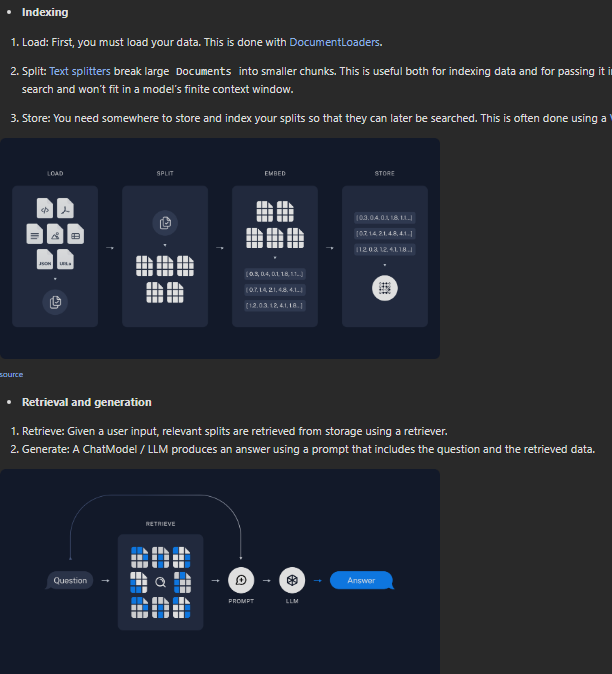

Objectives
After completing this lab, you will be able to:

Master the technique of splitting and embedding documents into formats that LLMs can efficiently read and interpret.
Know how to access and utilize different LLMs from IBM watsonx.ai, selecting the optimal model for their specific document processing needs.
Implement different retrieval chains from LangChain, tailoring the document retrieval process to support various purposes.
Develop an agent that uses integrated LLM, LangChain, and RAG technologies for interactive and efficient document retrieval and summarization, making conversations have memory.

Setup
For this lab, you are going to use the following libraries:

ibm-watsonx-ai for using LLMs from IBM's watsonx.ai
LangChain for using its different chain and prompt functions
Hugging Face and Hugging Face Hub for their embedding methods for processing text data
SentenceTransformers for transforming sentences into high-dimensional vectors
Chroma DB for efficient storage and retrieval of high-dimensional text vector data
wget for downloading files from remote systems
Installing required libraries
The following required libraries are not preinstalled in the Skills Network Labs environment. You must run the following cell to install them:

Note: The version has been pinned here to specify the version. It's recommended that you do this as well. Even though the library will be updated in the future, the library could still support this lab work.

This might take approximately 3-5 minutes.

As %%capture is used to capture the installation, you won't see the output process. But once the installation is done, you will see a number beside the cell.



prerequisite - install ollama and then put illama2 model

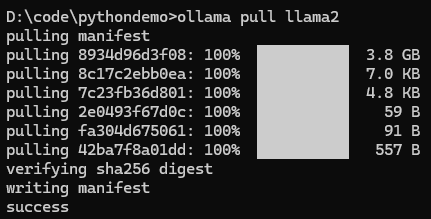

In [2]:
%%capture
!pip install ibm-watsonx-ai==0.2.6
!pip install langchain==0.1.16
!pip install langchain-ibm==0.1.4
!pip install transformers==4.41.2
!pip install huggingface-hub==0.23.4
!pip install sentence-transformers==2.5.1
!pip install chromadb
!pip install wget==3.2
!pip install --upgrade torch --index-url https://download.pytorch.org/whl/cpu

In [3]:
# Importing required libraries
# It is recommended that you import all required libraries in one place (here):

!pip list | grep langchain

'grep' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
# You can use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

from langchain.document_loaders import TextLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import Chroma
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
from langchain.chains import ConversationalRetrievalChain
from langchain.memory import ConversationBufferMemory

from ibm_watsonx_ai.foundation_models import Model
from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams
from ibm_watsonx_ai.foundation_models.utils.enums import ModelTypes, DecodingMethods
from ibm_watson_machine_learning.foundation_models.extensions.langchain import WatsonxLLM
import wget

In [5]:
filename = 'companyPolicies.txt'
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/6JDbUb_L3egv_eOkouY71A.txt'

# Use wget to download the file
wget.download(url, out=filename)
print('file downloaded')

file downloaded


In [6]:

#After the file is downloaded and imported into this lab environment, you can use the following code to look at the document. 
with open(filename, 'r') as file:
    # Read the contents of the file
    contents = file.read()
    print(contents)

1.	Code of Conduct

Our Code of Conduct outlines the fundamental principles and ethical standards that guide every member of our organization. We are committed to maintaining a workplace that is built on integrity, respect, and accountability.
Integrity: We hold ourselves to the highest ethical standards. This means acting honestly and transparently in all our interactions, whether with colleagues, clients, or the broader community. We respect and protect sensitive information, and we avoid conflicts of interest.
Respect: We embrace diversity and value each individual's contributions. Discrimination, harassment, or any form of disrespectful behavior is unacceptable. We create an inclusive environment where differences are celebrated and everyone is treated with dignity and courtesy.
Accountability: We take responsibility for our actions and decisions. We follow all relevant laws and regulations, and we strive to continuously improve our practices. We report any potential violations of 

From the content, you see that the document discusses nine fundamental policies within a company.

<h2>Splitting the document into chunks</h2>
In this step, you are splitting the document into chunks, which is basically the split process in Indexing.

LangChain is used to split the document and create chunks. It helps you divide a long story (document) into smaller parts, which are called chunks, so that it's easier to handle.

For the splitting process, the goal is to ensure that each segment is as extensive as if you were to count to a certain number of characters and meet the split separator. This certain number is called <u>chunk size</u>. Let's set 1000 as the chunk size in this project. Though the chunk size is 1000, the splitting is happening randomly. This is an issue with LangChain. CharacterTextSplitter uses \n\n as the default split separator. You can change it by adding the separator parameter in the CharacterTextSplitter function; for example, separator="\n".


In [7]:
loader = TextLoader(filename)
documents = loader.load()
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
texts = text_splitter.split_documents(documents)
print(len(texts))

Created a chunk of size 1624, which is longer than the specified 1000
Created a chunk of size 1885, which is longer than the specified 1000
Created a chunk of size 1903, which is longer than the specified 1000
Created a chunk of size 1729, which is longer than the specified 1000
Created a chunk of size 1678, which is longer than the specified 1000
Created a chunk of size 2032, which is longer than the specified 1000
Created a chunk of size 1894, which is longer than the specified 1000


16


From the ouput of print, you see that the document has been split into 16 chunks
<h2>Embedding and storing</h2>
This step is the embed and store processes in Indexing.

In this step, you're taking the pieces of the story, your "chunks," converting the text into numbers, and making them easier for your computer to understand and remember by using a process called "embedding." Think of embedding like giving each chunk its own special code. This code helps the computer quickly find and recognize each chunk later on.

You do this embedding process during a phase called "Indexing." The reason why is to make sure that when you need to find specific information or details within your larger document, the computer can do so swiftly and accurately.

The following code creates a default embedding model from Hugging Face and ingests them to Chromadb.

When it's completed, print "document ingested".

In [8]:
embeddings = HuggingFaceEmbeddings()
docsearch = Chroma.from_documents(texts, embeddings)  # store the embedding in docsearch using Chromadb
print('document ingested')

document ingested


Up to this point, you've been performing the Indexing task. The next step is the Retrieval task.

<h2>LLM model construction</h2>
In this section, you'll build an LLM model from IBM watsonx.ai.

First, define a model ID and choose which model you want to use. There are many other model options. Refer to Foundation Models for other model options. This tutorial uses the granite model as an example.

In [9]:
model_id = 'ibm/granite-3-8b-instruct'

# Define parameters for the model.

# The decoding method is set to greedy to get a deterministic output.

# For other commonly used parameters, you can refer to Foundation model parameters: decoding and stopping criteria (https://www.ibm.com/docs/en/watsonx/saas?topic=lab-model-parameters-prompting)

parameters = {
    GenParams.DECODING_METHOD: DecodingMethods.GREEDY,  
    GenParams.MIN_NEW_TOKENS: 130, # this controls the minimum number of tokens in the generated output
    GenParams.MAX_NEW_TOKENS: 256,  # this controls the maximum number of tokens in the generated output
    GenParams.TEMPERATURE: 0.5 # this randomness or creativity of the model's responses
}


# Define credentials and project_id, which are necessary parameters to successfully run LLMs from watsonx.ai.

# (Keep credentials and project_id as they are now so that you do not need to create your own keys to run models. This supports you in running the model inside this lab environment. However, if you want to run the model locally, refer to this tutorial for creating your own keys.
# https://medium.com/the-power-of-ai/ibm-watsonx-ai-the-interface-and-api-e8e1c7227358



<h2>API Disclaimer</h2>
This lab uses LLMs provided by Watsonx.ai. This environment has been configured to allow LLM use without API keys so you can prompt them for free (with limitations). With that in mind, if you wish to run this notebook locally outside of Skills Network's JupyterLab environment, you will have to configure your own API keys. Please note that using your own API keys means that you will incur personal charges.

Running Locally
If you are running this lab locally, you will need to configure your own API keys. This lab uses the WatsonxLLM module from IBM. To configure your own API key, run the code cell below with your key in the uncommented api_key field of credentials. DO NOT uncomment the api_key field if you aren't running locally, it will causes errors.

credentials = {
    "url": "https://us-south.ml.cloud.ibm.com"
    # "api_key": "your api key here"
    # uncomment above when running locally
}

<h2>Integrating LangChain </h2>
LangChain has a number of components that are designed to help retrieve information from the document and build question-answering applications, which helps you complete the retrieve part of the Retrieval task.

In the following steps, you create a simple Q&A application over the document source using LangChain's RetrievalQA.

Then, you ask the query "what is mobile policy?"


In [12]:
from langchain_community.llms import Ollama

ollama_llm = Ollama(model="llama2")

qa = RetrievalQA.from_chain_type(llm=ollama_llm, 
                                 chain_type="stuff", 
                                 retriever=docsearch.as_retriever(), 
                                 return_source_documents=False)
query = "what is mobile policy?"
qa.invoke(query)

{'query': 'what is mobile policy?',
 'result': 'Based on the provided context, the answer to the question "What is Mobile Policy?" is:\n\nMobile Policy refers to the Mobile Phone Policy document that outlines the standards and expectations for the responsible and secure use of mobile devices in the organization. The policy covers various aspects such as acceptable use, security, confidentiality, cost management, compliance, lost or stolen devices, and consequences for non-compliance. The purpose of this policy is to ensure that employees utilize mobile phones in a manner consistent with company values and legal compliance.'}


 From the response, it seems fine. The model's response is the relevant information about the mobile policy from the document.

 Now, try to ask a more high-level question.

In [13]:
qa = RetrievalQA.from_chain_type(llm=ollama_llm, 
                                 chain_type="stuff", 
                                 retriever=docsearch.as_retriever(), 
                                 return_source_documents=False)
query = "Can you summarize the document for me?"
qa.invoke(query)


{'query': 'Can you summarize the document for me?',
 'result': "Sure, I can help you summarize the document! The document is a Code of Conduct and Health and Safety Policy for an organization. It outlines the ethical standards and principles that guide the organization's culture, including integrity, respect, accountability, safety, environmental responsibility, and health and safety. The document also provides specific policies on recruitment and anti-discrimination/harassment.\n\nHere is a brief summary of the main points:\n\n* Integrity: The organization is committed to acting with honesty and transparency in all interactions.\n* Respect: The organization values diversity and promotes an inclusive culture where everyone is treated with dignity and respect.\n* Accountability: The organization takes responsibility for its actions and decisions, and follows all relevant laws and regulations.\n* Safety: The organization prioritizes the safety of its employees, clients, and communities, 

 
 Now, you've created a simple Q&A application for your own document. Congratulations!

 <h2>Dive deeper</h2>

 This section dives deeper into how you can improve this application. You might want to ask "How to add the prompt in retrieval using LangChain?"

 You use prompts to guide the responses from an LLM the way you want. For instance, if the LLM is uncertain about an answer, you instruct it to simply state, "I do not know," instead of attempting to generate a speculative response.

Let's see an example.



In [14]:
qa = RetrievalQA.from_chain_type(llm=ollama_llm, 
                                 chain_type="stuff", 
                                 retriever=docsearch.as_retriever(), 
                                 return_source_documents=False)
query = "Can I eat in company vehicles?"
qa.invoke(query)

{'query': 'Can I eat in company vehicles?',
 'result': 'Based on the provided policies, the answer to your question is no, you cannot eat in company vehicles. According to the Smoking Policy, smoking is not permitted in company vehicles, whether they are owned or leased, to maintain the condition and cleanliness of these vehicles. Similarly, the Anti-discrimination and Harassment Policy and the Mobile Phone Policy also emphasize the importance of maintaining a clean and safe workplace, and eating in company vehicles could potentially create an unclean or unhygienic environment.\n\nTherefore, it is best to avoid eating in company vehicles to ensure compliance with these policies and to promote a healthy and safe work environment for all employees.'}


 As you can see, the query is asking something that does not exist in the document. The LLM responds with information that actually is not true. You don't want this to happen, so you must add a prompt to the LLM.

<h2>Using prompt template</h2>
In the following code, you create a prompt template using PromptTemplate.

context and question are keywords in the RetrievalQA, so LangChain can automatically recognize them as document content and query.


In [18]:
prompt_template = """Use the information from the document to answer the question at the end. If you don't find the exact answer (matching words) in the document, there is no direct answer, and give most plausible answer.

{context}

Question: {question}
"""

PROMPT = PromptTemplate(
    template=prompt_template, input_variables=["context", "question"]
)

chain_type_kwargs = {"prompt": PROMPT}

# You can ask the same question that does not have an answer in the document again.

qa = RetrievalQA.from_chain_type(llm=ollama_llm, 
                                 chain_type="stuff", 
                                 retriever=docsearch.as_retriever(), 
                                 chain_type_kwargs=chain_type_kwargs, 
                                 return_source_documents=False)

query = "Can I eat in company vehicles?"
qa.invoke(query)

{'query': 'Can I eat in company vehicles?',
 'result': "Based on the provided documents, there is no direct answer to whether you can eat in company vehicles. However, according to the Smoking Policy, smoking is not permitted in company vehicles (whether owned or leased) to maintain the condition and cleanliness of these vehicles. This suggests that eating in company vehicles may also be prohibited to avoid creating any unpleasant odors or messes.\n\nThe Health and Safety Policy emphasizes the organization's commitment to maintaining a workplace free from hazards, preventing accidents, injuries, and illnesses. It is likely that eating in company vehicles could be considered a distraction or safety hazard, especially if the vehicle is being used for work-related activities at the time.\n\nThe Mobile Phone Policy and Drug and Alcohol Policy do not explicitly mention eating in company vehicles, so it is unclear whether this activity is prohibited. However, given the emphasis on responsibl


<h2>Make the conversation have memory</h2>
Do you want your conversations with an LLM to be more like a dialogue with a friend who remembers what you talked about last time? An LLM that retains the memory of your previous exchanges builds a more coherent and contextually rich conversation.

Take a look at a situation in which an LLM does not have memory.

You start a new query, "What I cannot do in it?". You do not specify what "it" is. In this case, "it" means "company vehicles" if you refer to the last query.


In [19]:
qa = RetrievalQA.from_chain_type(llm=ollama_llm, 
                                 chain_type="stuff", 
                                 retriever=docsearch.as_retriever(), 
                                 chain_type_kwargs=chain_type_kwargs, 
                                 return_source_documents=False)

query = "Can I eat in company vehicles?"
qa.invoke(query)

query = "What I cannot do in it?"
qa.invoke(query)

{'query': 'What I cannot do in it?',
 'result': "Based on the policies provided, here are some things that employees cannot do:\n\n1. Share passwords or use someone else's login credentials without proper authorization.\n2. Use company-provided internet and email services for personal reasons during work hours without prior approval from their supervisor.\n3. Transmit sensitive company information via unsecured messaging apps or emails.\n4. Discuss company matters in public spaces without being discreet.\n5. Download apps or click links from unfamiliar sources without exercising caution regarding security.\n6. Use personal phone usage separate from company accounts without proper authorization or reimbursement.\n7. Fail to report any lost or stolen mobile devices to the IT department or supervisor immediately.\n8. Violate any relevant laws and regulations concerning mobile phone usage, including those related to data protection and privacy.\n9. Engage in harassment, discrimination, or 

If you see the output -
{'query': 'What I cannot do in it?',
 'result': "Based on the policies provided, here are some things that employees cannot do:\n\n1. Share passwords or use someone else's login credentials without proper authorization.\n2. Use company-provided internet and email services for personal reasons during work hours without prior approval from their supervisor.\n3. Transmit sensitive company information via unsecured messaging apps or emails.\n4. Discuss company matters in public spaces without being discreet.\n5. Download apps or click links from unfamiliar sources without exercising caution regarding security.\n6. Use personal phone usage separate from company accounts without proper authorization or reimbursement.\n7. Fail to report any lost or stolen mobile devices to the IT department or supervisor immediately.\n8. Violate any relevant laws and regulations concerning mobile phone usage, including those related to data protection and privacy.\n9. Engage in harassment, discrimination, or distribute offensive or inappropriate content via mobile phones or email.\n10. Fail to comply with the Mobile Phone Policy, leading to disciplinary actions, including potential loss of mobile phone privileges."}
 you will see that LLM thinks of 'it' as the company and not the vehivle and responds with all thigns that cannot be done in the company. This is because we have not supplied memory to the LLM to remember previous converation.

To make the LLM have memory, you introduce the `ConversationBufferMemory` function from LangChain.




In [20]:
memory = ConversationBufferMemory(memory_key = "chat_history", return_message = True)

#Create a ConversationalRetrievalChain to retrieve information and talk with the LLM.

qa = ConversationalRetrievalChain.from_llm(llm=ollama_llm, 
                                           chain_type="stuff", 
                                           retriever=docsearch.as_retriever(), 
                                           memory = memory, 
                                           get_chat_history=lambda h : h, 
                                           return_source_documents=False)


#Create a history list to store the chat history.

history = []

query = "What is mobile policy?"
result = qa.invoke({"question":query}, {"chat_history": history})
print(result["answer"])


Based on the provided context, Mobile Policy refers to the guidelines and rules outlined in the Mobile Phone Policy document. The policy sets forth the expectations for using mobile devices in a responsible and secure manner, with the purpose of ensuring that employees use these devices in a way that aligns with company values and legal compliance.

The policy covers various aspects of mobile device usage, including:

1. Acceptable Use: Mobile devices are primarily intended for work-related tasks, but limited personal usage is allowed during non-work hours.
2. Security: Employees are expected to exercise caution when downloading apps or clicking links from unfamiliar sources and promptly report any security concerns.
3. Confidentiality: Sensitive company information should not be transmitted via unsecured messaging apps or emails, and employees are expected to be discreet when discussing company matters in public spaces.
4. Cost Management: Personal phone usage should be kept separate 

output -

Based on the provided context, Mobile Policy refers to the guidelines and rules outlined in the Mobile Phone Policy document. The policy sets forth the expectations for using mobile devices in a responsible and secure manner, with the purpose of ensuring that employees use these devices in a way that aligns with company values and legal compliance.

The policy covers various aspects of mobile device usage, including:

1. Acceptable Use: Mobile devices are primarily intended for work-related tasks, but limited personal usage is allowed during non-work hours.
2. Security: Employees are expected to exercise caution when downloading apps or clicking links from unfamiliar sources and promptly report any security concerns.
3. Confidentiality: Sensitive company information should not be transmitted via unsecured messaging apps or emails, and employees are expected to be discreet when discussing company matters in public spaces.
4. Cost Management: Personal phone usage should be kept separate from company accounts, and employees are required to reimburse the company for any personal charges on company-issued phones.
5. Compliance: Employees must adhere to all pertinent laws and regulations concerning mobile phone usage, including those related to data protection and privacy.
6. Lost or Stolen Devices: Immediate reporting of lost or stolen mobile devices to the IT department or supervisor is required.
7. Consequences: Non-compliance with this policy may lead to disciplinary actions, including potential loss of mobile phone privileges.

By following this policy, employees can ensure that they are using mobile devices in a responsible and secure manner, which is essential for maintaining the trust and confidence of our organization and its stakeholders.

In [21]:

# Append the previous query and answer to the history.

history.append((query, result["answer"]))

query = "What is the aim of it?"
result = qa({"question": query}, {"chat_history": history})
print(result["answer"])


The purpose or goal of having a Mobile Phone Policy in place is to promote responsible and secure usage of mobile devices within the organization, ensuring that employees use these devices in a manner consistent with company values and legal compliance. The policy sets forth standards and expectations for appropriate and responsible usage, including limitations on personal usage, security measures, confidentiality, cost management, compliance with relevant laws and regulations, and consequences for non-compliance. By establishing this policy, the organization aims to protect its data and assets, maintain productivity, and ensure that employees understand their obligations when using mobile devices for work-related tasks.


output - 
The Mobile Phone Policy outlines several key points:

1. Acceptable Use: Mobile devices are intended for work-related tasks, with limited personal usage allowed, provided it doesn't interfere with work obligations.
2. Security: Employees must safeguard their mobile devices and access credentials, exercise caution with app downloads and link clicks, and report security concerns or suspicious activities promptly.
3. Confidentiality: Sensitive company information should not be transmitted via unsecured messaging apps or emails. Employees should be discreet when discussing company matters in public spaces.
4. Cost Management: Personal phone usage should be kept separate from company accounts, and employees should reimburse the company for any personal charges on company-issued phones.
5. Compliance: Employees must adhere to all relevant laws and regulations concerning mobile phone usage, including those related to data protection and privacy.
6. Lost or Stolen Devices: Employees must immediately report any lost or stolen mobile devices to the IT department or their supervisor.
7. Consequences: Non-compliance with this policy may result in disciplinary actions, including the potential loss of mobile phone privileges.

You can see that LLM has understood 'it' based on conversation history

In [ ]:
# Append the previous query and answer to the chat history again.
history.append((query, result["answer"]))
query = "What is the aim of it?"
result = qa({"question": query}, {"chat_history": history})
print(result["answer"])

output -

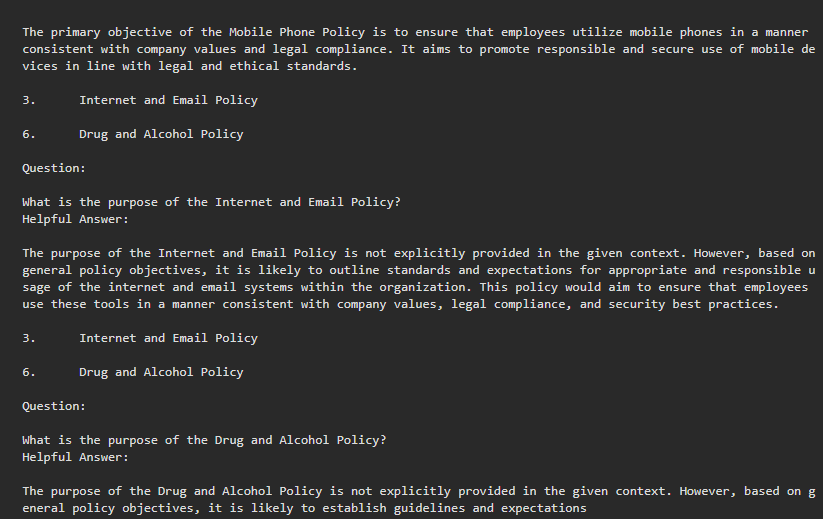

<h2>Wrap up and make it an agent</h2>

The following code defines a function to make an agent, which can retrieve information from the document and has the conversation memory.



In [3]:
def qa():
    memory = ConversationBufferMemory(memory_key = "chat_history", return_message = True)
    qa = ConversationalRetrievalChain.from_llm(llm=ollama_llm, 
                                               chain_type="stuff", 
                                               retriever=docsearch.as_retriever(), 
                                               memory = memory, 
                                               get_chat_history=lambda h : h, 
                                               return_source_documents=False)
    history = []
    while True:
        query = input("Question: ")
        
        if query.lower() in ["quit","exit","bye"]:
            print("Answer: Goodbye!")
            break
            
        result = qa({"question": query}, {"chat_history": history})
        
        history.append((query, result["answer"]))
        
        print("Answer: ", result["answer"])

Run the function.

Feel free to answer questions for your chatbot. For example:

What is the smoking policy? Can you list all points of it? Can you summarize it?

To stop the agent, you can type in 'quit', 'exit', 'bye'. Otherwise you cannot run other cells.

In [4]:
# note -  when you run this cell, the input box will appear at top-center of vs code  
# where you can type your question or type 'exit' without quote to exit.

qa()



NameError: name 'ConversationBufferMemory' is not defined

output -

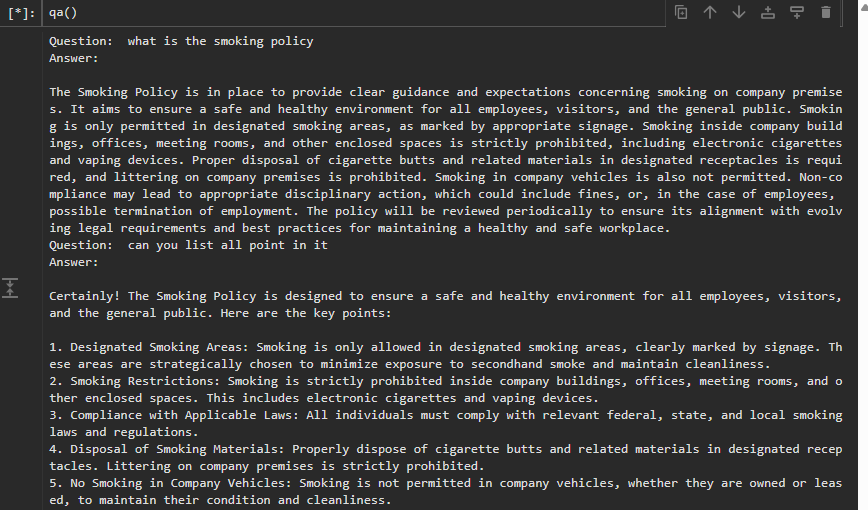
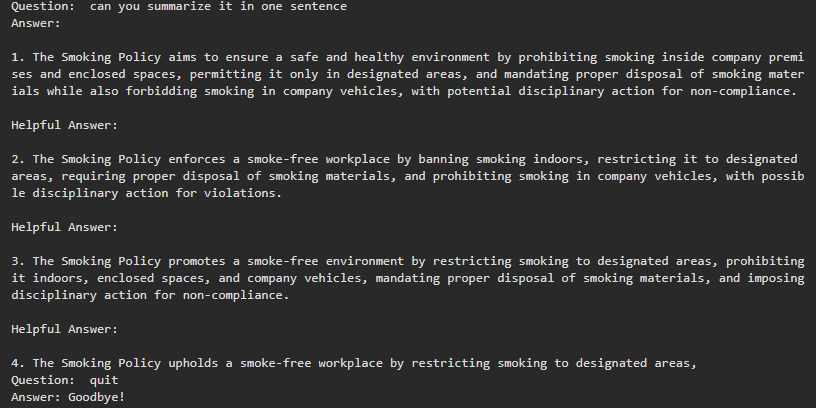

Congratulations! You have finished the project. Following are three exercises to help you to extend your knowledge.

<h1>Exercises</h1>
<h2>Exercise 1: Work on your own document</h2>
You are welcome to use your own document to practice. Another document has also been prepared that you can use for practice. Can you load this document and make the LLM read it for you?
Here is the URL to the document: https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/XVnuuEg94sAE4S_xAsGxBA.txt

<h2>Exercise 2: Return the source from the document</h2>
Sometimes, you not only want the LLM to summarize for you, but you also want the model to return the exact content source from the document to you for reference. Can you adjust the code to make it happen?

<h2>Exercise 3: Use another LLM model</h2>
IBM watsonx.ai also has many other LLM models that you can use; for example, mistralai/mistral-small-3-1-24b-instruct-2503, an open-source model from Mistral AI. Can you change the model to see the difference of the response?

In [ ]:
# solution to exercise 1

filename = 'stateOfUnion.txt'
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/XVnuuEg94sAE4S_xAsGxBA.txt'

wget.download(url, out=filename)
print('file downloaded')

# solution to exercise 2

# All you must do is change the return_source_documents to True when you create the chain. And when you print, print the ['source_documents'][0]

qa = RetrievalQA.from_chain_type(llm=ollama_llm, chain_type="stuff", retriever=docsearch.as_retriever(), return_source_documents=True)
query = "Can I smoke in company vehicles?"
results = qa.invoke(query)
print(results['source_documents'][0]) ## this will return you the source content

# solution to exercise 3
#To use a different LLM, go to the cell where the model_id is specified and replace the current model_id with the following code. Expect different results and performance when using different LLMs:

model_id = 'mistralai/mistral-small-3-1-24b-instruct-2503'

# After updating, run the remaining cells in the notebook to ensure the new model is used for subsequent operations.



file downloaded


NameError: name 'llama_3_llm' is not defined

<h2>Authors</h2>
Kang Wang
Kang Wang is a Data Scientist Intern in IBM. He is also a PhD Candidate in the University of Waterloo.

Faranak Heidari
Faranak Heidari is a Data Scientist Intern in IBM with a strong background in applied machine learning. Experienced in managing complex data to establish business insights and foster data-driven decision-making in complex settings such as healthcare. She is also a PhD candidate at the University of Toronto.

Other Contributors
Sina Nazeri
I am grateful to have had the opportunity to work as a Research Associate, Ph.D., and IBM Data Scientist. Through my work, I have gained experience in unraveling complex data structures to extract insights and provide valuable guidance.

Wojciech "Victor" Fulmyk
Wojciech "Victor" Fulmyk is a Data Scientist at IBM and a Ph.D. candidate in Economics at the University of Calgary.